-----
# BERT
-------

## Set Up
----

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
import spacy

In [130]:
import torch
from torch.utils.data import DataLoader, TensorDataset

In [131]:
from transformers import DistilBertModel, DistilBertTokenizer

## Data Loading and Preparation
----

In [132]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [133]:
emails_df['all_text'] = emails_df['cleaned_subject'] + ' ' + emails_df['cleaned_body']

In [134]:
nlp = spacy.load('en_core_web_sm')

In [135]:
def remove_names(text):
    text = str(text)
    doc = nlp(text)
    for e in reversed(doc.ents):
        if e.label_ in ("PERSON", "ORG", "DATE",): 
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text

In [136]:
emails_df['all_text'] = emails_df['all_text'].apply(remove_names)

## Tokenising Emails
----

In [52]:
tokeniser = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

In [56]:
def tokenise_and_chunk(email, chunk_size=512, padding_token=0):
    """
    Tokenizes the email, automatically truncates if necessary, and splits into chunks of size `chunk_size` with padding and attention mask.
    """
    # Tokenize the email, automatically truncating it to chunk_size, and adding special tokens
    tokens = tokeniser.encode(email, add_special_tokens=True, max_length=chunk_size, truncation=False)

    chunks = []
    attention_masks = []
    
    # Split tokens into chunks
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        
        # If the chunk is smaller than chunk_size, pad it
        if len(chunk) < chunk_size:
            padding_length = chunk_size - len(chunk)
            chunk = chunk + [padding_token] * padding_length
        
        # Attention mask: 1 for real tokens, 0 for padding
        mask = [1 if token != padding_token else 0 for token in chunk]

        chunks.append(chunk)
        attention_masks.append(mask)

    return chunks, attention_masks

In [ ]:
tokened_emails = []
attention_masks = []

for email in emails_df['all_text']:
    # chunk each email and tokenise each chunk
    chunks, mask = tokenise_and_chunk(email, chunk_size=512, padding_token=0)

    tokened_emails.extend(chunks)
    attention_masks.extend(mask)


## BERT expects inputs to be tensors
-----

In [58]:
# Using torch to create tensors for the tokened_emails and attention_masks
input_tensors = torch.tensor(tokened_emails)
attention_masks = torch.tensor(attention_masks)

In [59]:
# Creating tensor dataset to make training faster
dataset = TensorDataset(input_tensors, attention_masks)

### Sanity Check on encoding by decoding 

In [15]:
decoded_chunks = []

for tokened_email in tokened_emails:
    decoded_email_chunks = []
    for chunk in tokened_email:
        # If chunk is a tensor, convert to a list first
        if isinstance(chunk, torch.Tensor):
            chunk = chunk.tolist()  # Convert tensor to list of token IDs
        
        # Decode each chunk and skip special tokens
        decoded_chunk = tokeniser.decode(chunk, skip_special_tokens=True)

        # Join tokens with no spaces between subwords (concatenate parts like '##land' + 'a')
        decoded_chunk = decoded_chunk.replace(' ##', '')  # Remove space before subword tokens
        
        decoded_email_chunks.append(decoded_chunk)
    
    decoded_chunks.append(decoded_email_chunks)

# Print decoded chunks for debugging
print(decoded_chunks[1])  # Check the first decoded email


['', 'refining', 'llc', 'yo', '##landa', 'in', 'connection', 'with', 'the', 'execution', 'of', 'the', 'is', '##da', 'master', 'agreement', 'with', 'requires', 'that', 'they', 'provide', 'the', 'following', 'documentation', '1', 'form', 'w', '##9', 'request', 'for', 'taxpayer', 'identification', 'number', '2', 'certificate', 'of', 'inc', '##umb', '##ency', 'ce', '##rti', '##fying', 'i', 'a', 'true', 'and', 'correct', 'copy', 'of', 'the', 'certificate', 'of', 'organization', 'or', 'formation', 'and', 'operating', 'agreement', 'and', 'ii', 'the', 'inc', '##umb', '##ency', 'and', 'specimen', 'signature', 'of', 'the', 'officer', 'executing', 'the', 'on', 'behalf', 'of', 'the', 'sole', 'member', '##mana', '##ger', 'of', 'secretary', 'of', 'refining', 'ce', '##rti', '##fying', 'resolutions', 'author', '##izing', 'i', 'the', 'execution', 'of', 'the', 'is', '##da', 'master', 'agreement', 'and', 'ii', 'the', 'execution', 'of', 'energy', 'price', 'swap', 'and', 'option', 'transactions', 'i', 'am'

In [16]:
emails_df['all_text'].iloc[1]

' Refining LLC Yolanda In connection with the execution of the ISDA Master Agreement with  requires that they provide the following documentation 1  Form W9 Request for Taxpayer Identification Number 2 Certificate of Incumbency certifying i a true and correct copy of the certificate of organization or formation and operating agreement and ii the incumbency and specimen signature of the officer executing the  on behalf of the sole membermanager of  Secretary of  Refining certifying resolutions authorizing i the execution of the ISDA Master Agreement and ii the execution of energy price swap and option transactions I am attaching forms of the certificates listed as items 2 and 3 above If  needs the  W9 they can go to their website at and download a copy  will be providing a Certificate of Incumbency certifying its articles of incorporation and bylaws and the incumbency and specimen signature of the officer executing the  on behalf of ENA together with a  certifying resolutions as to its 

## Forward Pass of model to get embeddings
---

In [ ]:
model = DistilBertModel.from_pretrained('distilbert-base-uncased')
# tells the model only interested in runnin ginputs through network, dont want any training
model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [61]:
# Creating bactches to speed up training as only using cpu
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)

In [62]:
all_email_embeddings = []

In [63]:
device = torch.device("cpu") # default is cpu but adding to make sure model aware of cpu not gpu
model.to(device)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [64]:
for batch_inputs, batch_attention_masks  in dataloader:

    # Forward pass through the model
    with torch.no_grad():
        outputs = model(input_ids=batch_inputs, attention_mask=batch_attention_masks)

    # Get the context embeddings (last hidden state weights)
    last_hidden_state = outputs.last_hidden_state

    # Take an average of the embeddigns to get a single number vector for each email
    email_embedding = last_hidden_state.mean(dim=1) # shape = [1, # hidden nodes]
    all_email_embeddings.append(email_embedding)


In [65]:
# unbatch the emails 
all_email_embeddings = torch.cat(all_email_embeddings, dim=0)

In [66]:
torch.save(all_email_embeddings, "email_embeddings.pt")

## Evaluate Embeddings 
----

### Visualising the Embeddings

In [92]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

In [93]:
embeddings_tensor = torch.load("sentence_embeddings.pt")

In [94]:
# make tensor an array
embeddings_array = embeddings_tensor.numpy() # make tensor an array

In [95]:
# using umap to reduce dims, tsne not effective for these embeddings
umap_model = umap.UMAP(
    n_neighbors=15,    
    min_dist=0.5,      
    metric='cosine',   
    n_components=2,     
    random_state=12     
)

/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


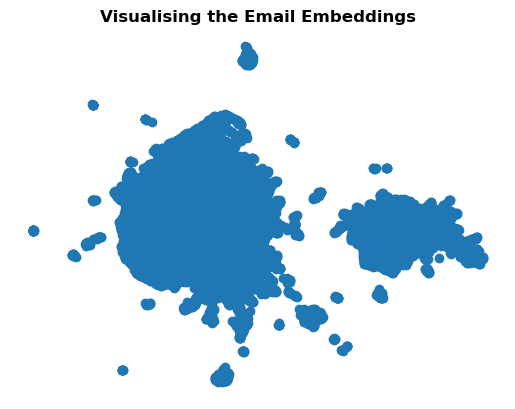

In [99]:
email_2d = umap_model.fit_transform(embeddings_array)

plt.scatter(email_2d[:, 0], email_2d[:, 1])
plt.title("Visualising the Email Embeddings", fontweight = 'bold')
plt.xticks([])
plt.yticks([])
plt.gca().spines[['top', 'bottom', 'right', 'left']].set_visible(False)
plt.show()

-----
**Comment:**

- The data shows two main clusters: one larger and one smaller.

- There is no clear boundary between the clusters and some noise is present, especially around the larger cluster.

- After testing different UMAP parameters, there hasn't been much improvement so am moving on to clustering the data to assess the labels.

### Assess Embedding Quality

In [102]:
from sklearn.metrics.pairwise import cosine_similarity

In [103]:
emails_df.reset_index(drop = True, inplace=True)

In [104]:
random_sample = emails_df.sample(10)
sample_indices = random_sample.index.tolist()
sample_embeddings = embeddings_array[sample_indices]

In [105]:
similarity_matrix = cosine_similarity(sample_embeddings)


In [106]:
similar_emails = []
dissimilar_emails = []

for i in range(len(sample_indices)):
    similarities = similarity_matrix[i]

    sorted_sims = similarities.argsort()[::-1]

    top_similar_indices = [idx for idx in sorted_sims if idx != i][:2]

    bottom_similar_indices = similarities.argsort()  # Ascending: least similar first
    top_dissimilar_indices = [idx for idx in bottom_similar_indices if idx != i][:2]
    
    similar_emails.append(random_sample.iloc[top_similar_indices]["all_text"].tolist())
    dissimilar_emails.append(random_sample.iloc[top_dissimilar_indices]["all_text"].tolist())



In [115]:
import textwrap

for i, idx in enumerate(random_sample.index):
    print('-' * 50)
    print(f"****** Sample Email #{i+1} *****")
    print("\nOriginal Email:")
    print(textwrap.fill(emails_df.loc[idx, "all_text"][:500], width=150)) 
    print("\nTop 2 Most Similar Emails:")
    for j, email in enumerate(similar_emails[i]):
        print(f"{j+1}. {textwrap.fill(email[:500], width=150)}\n")
    print("\nTop 2 Least Similar Emails:")
    for j, email in enumerate(dissimilar_emails[i]):
        print(f"{j+1}. {textwrap.fill(email[:500], width=150)}\n")


--------------------------------------------------
****** Sample Email #1 *****

Original Email:
Re Lunch For Rod Nelson Suzanne Marie is included Lets see how everyone else responds and hope that we can choose Mon Tues or Wed I would prefer Mon
or Tuesday because I see the doctor on Wed but lets see what works for everyone else Suzanne Adams 06162000 0505 PM cc AdamsHOUECT on 06162000 0505 PM
Marie COMMUNICATIONS 06162000 0454 PM cc Am I really included in this lunch If so I will be out Thursday and Friday June 29 and 30 Thanks Marie Heard
Senior Legal Specialist Enron Broadband Services P

Top 2 Most Similar Emails:
1. FW Olympic Hopefuls LoiblHOUECT on 09222000 0501 PM 09222000 0407 PM DANA Gallegos Kelli K Angela ConnellyLONECT BigTex Sports ENRON Bryan gossett
ENRON Lauren Coleman Sherlyn Alfonso John cc In the spirit of the Olympics See attached file GOLDMPG See attached file SILVERMPG See attached file
BRONZEMPG See attached file JAVELINMPG GOLDMPG SILVERMPG BRONZEMPG JAVELINMPG

-----
**Comment:**

Considering the noisiness of the Enron email dataset, out-of-the-box BERT doesn't seem to perform too poorly on real-world emails. The model does show some meaningful grouping based on topic and tone — for example, legal and finance-related emails often appear together, and casual or personal messages (e.g., birthday wishes, virus warnings) also tend to cluster.

But it struggles in separating messages with mixed vocabulary, such as operational updates that include both business and informal language.


### Clustering

In [116]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

#### 1. K-means

In [117]:
scaler = MinMaxScaler()
scaled_embeddings = scaler.fit_transform(embeddings_array)

In [118]:
k_vals = np.arange(2,11,1)

In [119]:
# finding optimal k uisng scree plot
labels = []
inertia = []
silhouette_scores = []

for k in k_vals:
    kmeans = KMeans(n_clusters=k, random_state=11)
    kmeans.fit(scaled_embeddings)

    labels.append(kmeans.labels_)

    inertia.append(kmeans.inertia_)

    silhouette = silhouette_score(scaled_embeddings, kmeans.labels_)
    silhouette_scores.append(silhouette)

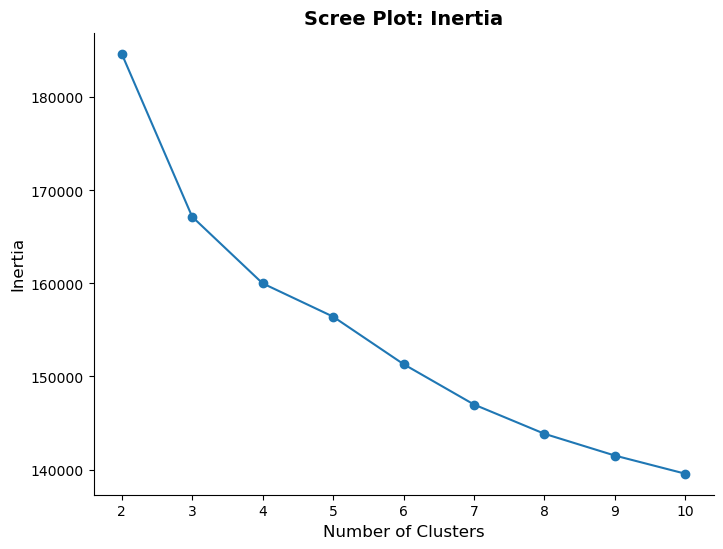

In [120]:
plt.figure(figsize=(8, 6))

plt.plot([k for k in k_vals], inertia, marker='o')
plt.title('Scree Plot: Inertia', fontsize=14, fontweight= 'bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

----
**Comment:**

- There is no clear elbow but the largest decrease in inertia score happens between k = 2 and k = 3. 
- Expected from umap visualisaion which suggests that there are two main clusters with a lot of noise.
- Given the high inertia scores, which remain above 260,000 even as k increases, it indicates that the separation between clusters is not clean. The points within each cluster are still far from the cluster centroids.

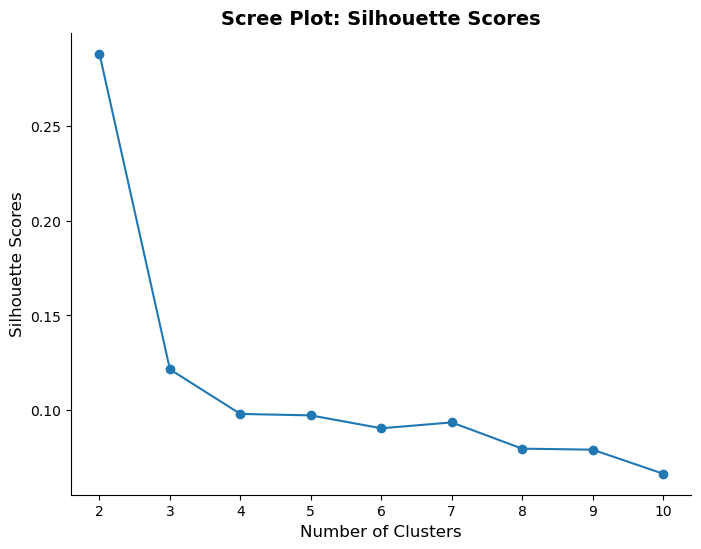

In [121]:
plt.figure(figsize=(8, 6))

plt.plot([k for k in k_vals], silhouette_scores, marker='o')
plt.title('Scree Plot: Silhouette Scores', fontsize=14, fontweight= 'bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Scores', fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

----
**Comment:**

- The silhouette scores for the different values of k are generally low, meaning that the clusters are not well-separated.
- k = 2 shows the best result, suggestign there is some meaningful separation but there is a lot of noise as we are not clsoe to 1. This is supported from the findings from umap plot.
- As k increases there is no real improvement in the separtion ot the clusters, this could be the clusters are now capturing noise as we increase k ?
- Again, best to explore different clustering techniques to see if we can get better results.

In [122]:
kmeans = KMeans(n_clusters=3, random_state=11)
kmeans.fit(scaled_embeddings)

labels = kmeans.labels_

In [123]:
print(f"Inertia score: {kmeans.inertia_}")
print(f"Silhouette score: {silhouette_score(scaled_embeddings, kmeans.labels_)}")

Inertia score: 167169.03125
Silhouette score: 0.12160083651542664


-----
**Comment:**

**Inertia: 167_169**

Shows how well the clusters are packed together, lower values indicate tighter clusters.

A score of 167_169 is quite high but does show some cohesion within the clusters, I think this is email data is rather noisy and even with attempts to clean up as much noise as possible i think using out of the box bert with no fine tuning tehse restuls make sense.

**Silhouette Score: 0.12**

A relatively low score, I wasn't expecting too good of a perrformance since I am using out ofg the box BERT on emails where language varies a lot depending on audience and context. 

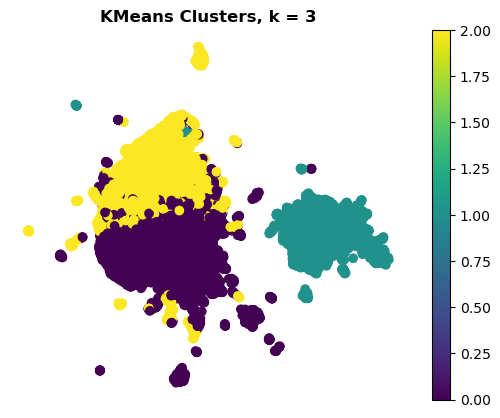

In [124]:
plt.scatter(email_2d[:, 0], email_2d[:, 1], c=labels, cmap='viridis')
plt.title("KMeans Clusters, k = 3", fontweight = 'bold')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.gca().spines[['bottom', 'left','top', 'right']].set_visible(False)
plt.show()


----
**Comment:**

- After experimenting with multiple cluster sizes,I thought that k=3 gets the best results and most distinct clusters.

- As shown in the plot, there are three clusters. The one to the right is well-separated from the other two clusters. The one thr left is larger and is not well separted. I did try k = 4 and k = 2, but neither produced as good results as k = 3 IMO. 



#### 2. DBSCAN

In [125]:
scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(embeddings_array)

----
**Comment:**

Performance with StandardScaler tends to be better for DBSCAN, and this could be due to the way each clustering method works. K-means uses distance calculations, so features with larger ranges can dominate. DBSCAN works better with StandardScaler because it normalises the data, ensuring that each feature contributes more equally without one feature skewing the density.


In [126]:
dbscan = DBSCAN(eps=0.4, min_samples=10, metric='cosine')
dbscan.fit(scaled_embeddings)


DBSCAN(eps=0.4, metric='cosine', min_samples=10)

In [127]:
labels = dbscan.labels_

In [128]:
np.unique(labels, return_counts=True)

(array([-1,  0,  1]), array([ 6518, 29127,     9]))

----
**Comment:**

Label -1 = 6,518 points
- These are noise points since DBSCAN couldn't assign them to any cluste as theyh don't meet the density requirement set by the params.

Label 0 = 29,127 points
- These points belong to Cluster 0, which is the main cluster detected by DBSCAN, most of the data falls under this label

Label 1 = 9 points
- Only 9 points were dense enough to be grouped together but separate from the main cluster.

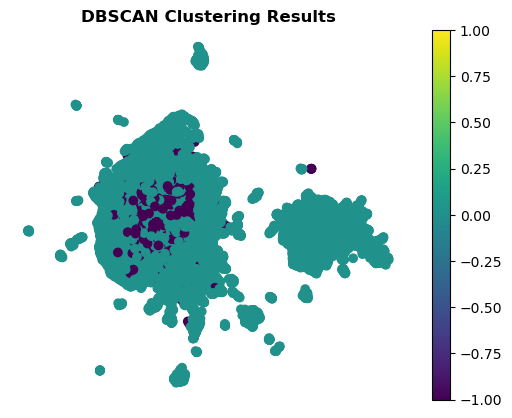

In [81]:
plt.scatter(email_2d[:, 0], email_2d[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN Clustering Results', fontweight='bold')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.gca().spines[['bottom', 'left','top', 'right']].set_visible(False)
plt.show()

----
**Comment:**

The DBSCAN plot shows most points in a single color, representing the largest cluster (label 0).

Interestingly, many purple points (noise, label -1) appear scattered even within the centre of the main cluster. This could indicate that some regions within the cluster are not dense enough and so are labelled as noise. It's also important to note that UMAP is 2D represenation, so points that appear in the middle may not be actually be in the centre of the cluster.

Points with label 1 are too few (only 9) to be clearly visible, likely due to overlap with noise or the dominant cluster, making them hard to distinguish in the plot.

